In [6]:
import pandas as pd
import numpy as np
import gc
from datasets import Dataset, load_from_disk
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report, f1_score, multilabel_confusion_matrix
import random 
import warnings
import transformers
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from torch.utils.data import DataLoader

warnings.filterwarnings('ignore', category=FutureWarning)
transformers.logging.set_verbosity_error()

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Load tokenized dataset

In [3]:
# Dataset stays on disk, rows load only when needed
tokenized_dataset = load_from_disk('../data/tokenized_for_roberta')
print(f"Loaded {len(tokenized_dataset):,} rows")

aspect_cols = [
             'product_quality_positive', 'product_quality_negative',
             'service_positive', 'service_negative',
             'wait_time_positive', 'wait_time_negative',
             'price_value_positive', 'price_value_negative',
             'cleanliness_positive', 'cleanliness_negative',
             'atmosphere_positive', 'atmosphere_negative',
             'general_positive', 'general_negative'
]            


random.seed(2)
sample = tokenized_dataset.select(random.sample(range(len(tokenized_dataset)), 100_000))
split = sample.train_test_split(test_size=0.1, seed=2)
test_subset = split['test']
print(f\nTest size: {len(test_subset):,}")

Loading dataset from disk:   0%|          | 0/35 [00:00<?, ?it/s]

Loaded 22,614,379 rows
Test size: 10,000


### Evaluation Metrics

In [4]:
# Define metrics
def compute_metrics(pred):
    """Compute evaluation metrics for multi-label classification."""
    labels = pred.label_ids
    preds = (pred.predictions > 0.5).astype(int)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted', zero_division=0
    )
    acc = accuracy_score(labels, preds)
    
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Final Model RoBERTa-base (100k Sample)

In [8]:
model = RobertaForSequenceClassification.from_pretrained(
    '../models/roberta_final',
    num_labels=len(aspect_cols),
    problem_type="multi_label_classification"
).to(device)
model.eval()

test_subset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
loader = DataLoader(test_subset, batch_size=128)

all_preds = []
with torch.no_grad():
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
        logits = model(**batch).logits
        preds = (torch.sigmoid(logits) > 0.5).cpu().numpy()
        all_preds.append(preds)

y_pred = np.vstack(all_preds)
y_true = np.array(test_subset['labels'])

print("RoBERTa - Test Set (100k Best Run)")
print(f"\nF1 Score (macro):    {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"F1 Score (weighted): {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=aspect_cols, zero_division=0))

RoBERTa - Test Set (100k Best Run)

F1 Score (macro):    0.8761
F1 Score (weighted): 0.9283

Classification Report:
                          precision    recall  f1-score   support

product_quality_positive       0.95      0.96      0.96      3117
product_quality_negative       0.85      0.79      0.82       771
        service_positive       0.96      0.97      0.96      2416
        service_negative       0.90      0.85      0.87       677
      wait_time_positive       0.93      0.91      0.92      1236
      wait_time_negative       0.85      0.80      0.82       444
    price_value_positive       0.93      0.94      0.93      1106
    price_value_negative       0.84      0.76      0.80       366
    cleanliness_positive       0.94      0.93      0.94       522
    cleanliness_negative       0.82      0.79      0.80       168
     atmosphere_positive       0.93      0.95      0.94       805
     atmosphere_negative       0.81      0.75      0.78       201
        general_positive 

## Evaluate Final Model on Ground Truth Validation set 

In [9]:
df_val = pd.read_csv('../data/manual_absa_eval_reviews.csv')

class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.encodings = tokenizer(list(texts), truncation=True, padding=True, max_length=max_len, return_tensors="pt")
    def __len__(self):
        return self.encodings["input_ids"].shape[0]
    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()}

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
val_dataset = ReviewDataset(df_val["text"].fillna(""), tokenizer)
loader = DataLoader(val_dataset, batch_size=64)

all_preds = []
with torch.no_grad():
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        logits = model(**batch).logits
        preds = (torch.sigmoid(logits) > 0.5).cpu().numpy()
        all_preds.append(preds)

y_pred = np.vstack(all_preds)
y_true = df_val[aspect_cols].values

print("RoBERTa - Validation Set (Manual Labels)")
print(f"\nF1 Score (macro):    {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"F1 Score (weighted): {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=aspect_cols, zero_division=0))

RoBERTa - Validation Set (Manual Labels)

F1 Score (macro):    0.5842
F1 Score (weighted): 0.6051

Classification Report:
                          precision    recall  f1-score   support

product_quality_positive       0.84      0.54      0.66       708
product_quality_negative       0.55      0.56      0.56       475
        service_positive       0.85      0.66      0.74       529
        service_negative       0.83      0.70      0.76       626
      wait_time_positive       0.39      0.82      0.53       101
      wait_time_negative       0.47      0.74      0.58       180
    price_value_positive       0.66      0.73      0.69       196
    price_value_negative       0.68      0.64      0.66       298
    cleanliness_positive       0.74      0.79      0.76        76
    cleanliness_negative       0.65      0.52      0.58       127
     atmosphere_positive       0.58      0.39      0.47       216
     atmosphere_negative       0.28      0.17      0.21       172
        general_pos

# Figures

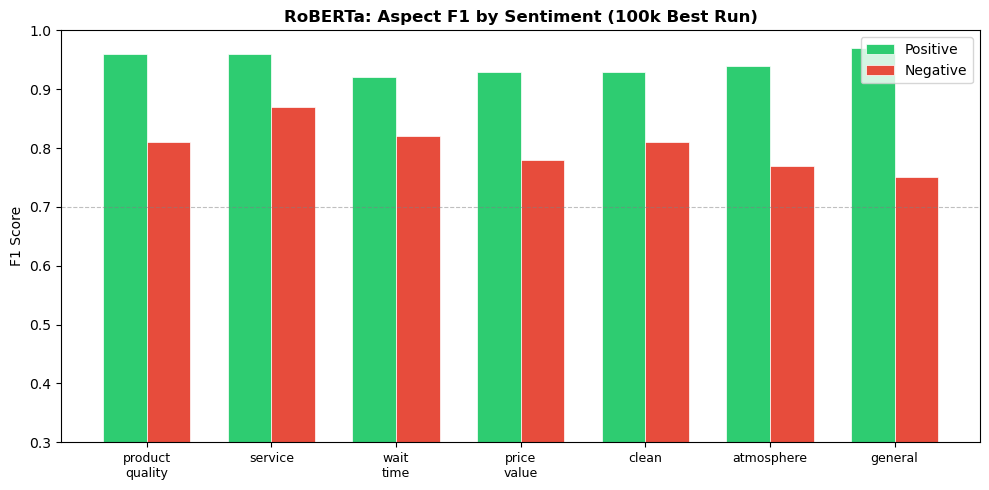

In [14]:
# Figure 5 — RoBERTa Aspect F1 by Sentiment (100k Best Run)
aspects = ['product\nquality', 'service', 'wait\ntime', 'price\nvalue', 'clean', 'atmosphere', 'general']
pos_f1  = [0.96, 0.96, 0.92, 0.93, 0.93, 0.94, 0.97]
neg_f1  = [0.81, 0.87, 0.82, 0.78, 0.81, 0.77, 0.75]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(aspects))
width = 0.35
ax.bar(x - width/2, pos_f1, width, label='Positive', color='#2ecc71', edgecolor='white', linewidth=0.5)
ax.bar(x + width/2, neg_f1, width, label='Negative', color='#e74c3c', edgecolor='white', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(aspects, fontsize=9)
ax.set_ylim(0.3, 1.0)
ax.set_title('RoBERTa: Aspect F1 by Sentiment (100k Best Run)', fontweight='bold')
ax.set_ylabel('F1 Score')
ax.legend()
ax.axhline(0.7, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('../figures/figure5_roberta_aspect_f1.png', dpi=150, bbox_inches='tight')
plt.show()

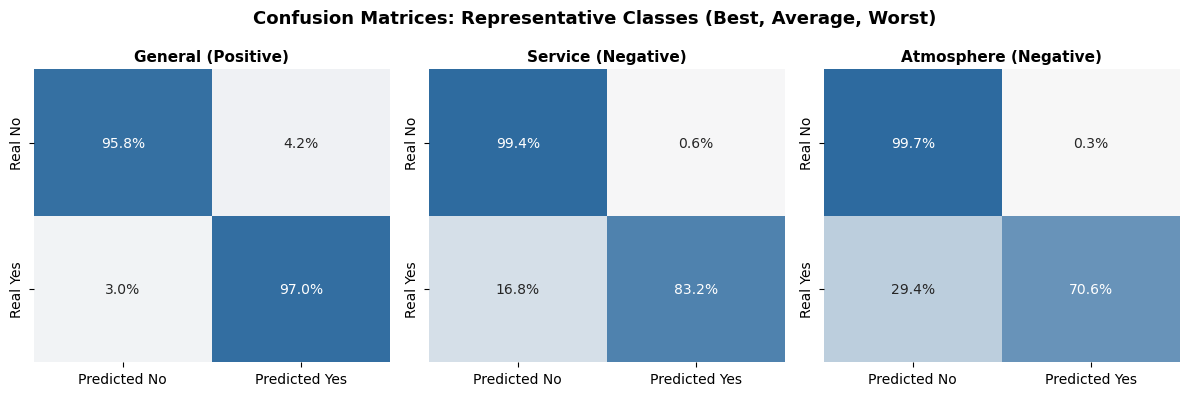

In [21]:
# Figure 6 
# RoBERTa Confusion Matrices

cmap = LinearSegmentedColormap.from_list('custom', ['#f7f7f7', '#2d6a9f'])

selected = ['general_positive', 'service_negative', 'atmosphere_negative']
titles   = ['General (Positive)', 'Service (Negative)', 'Atmosphere (Negative)']

# You'll need mcm from multilabel_confusion_matrix on your RoBERTa predictions
mcm = multilabel_confusion_matrix(y_true, y_pred)

selected_idx = [aspect_cols.index(s) for s in selected]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, idx, title in zip(axes, selected_idx, titles):
    tn, fp, fn, tp = mcm[idx].ravel()
    cm_data = np.array([[tn, fp], [fn, tp]])
    cm_pct = cm_data / cm_data.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm_pct, annot=True, fmt='.1f', ax=ax, cmap=cmap,
                xticklabels=['Predicted No', 'Predicted Yes'],
                yticklabels=['Real No', 'Real Yes'],
                cbar=False, vmin=0, vmax=100)
    ax.set_title(title, fontsize=11, fontweight='bold')

    for text in ax.texts:
        text.set_text(text.get_text() + '%')

plt.suptitle('Confusion Matrices: Representative Classes (Best, Average, Worst)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/figure6_roberta_confusion.png', dpi=150, bbox_inches='tight')
plt.show()